In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

# Exercises

1. Try the following commands, and understand their effect:

```python
A=np.bmat([[np.diag([1,2,3,4]), 2*np.eye(4)], [np.zeros([2,5]), 3*np.ones([2,3])]])
A=np.bmat([[np.diag([1,2,3,4]), 2*np.eye(4)], [np.zeros([2,5]), 3*np.ones([2,3])]])
np.shape(A)
B=A[1:4,4:-1]
A[1,2]=13, A[1:4,:]=5
A.T
np.sum(A), np.sum(A,2), np.sum(A,1), np.sum(np.sum(A))
x=np.linspace(-1,1,10)
np.where(x<0)
z=x[x<0]
y=2*np.ones(10)
x/y
m=np.arange(1,25,1)
m=np.reshape(m,[4,6])
np.amax(m)
np.amax(m,0)

In [ ]:
# Creates a matrix from other matrices
A = np.bmat(
    [[np.diag([1,2,3,4]), 2*np.eye(4)],
     [np.zeros([2,5]), 3*np.ones([2,3])]])
print(A, '\n')

# Computes the shape of A
print('Demensions of A', np.shape(A), '\n')

# Select the matrix from the region from row 2 to one row 4 and columns from the 5th but before the last
B = A[1:4, 4:-1]
print('Matrix B:', B, '\n')

# Replace the elements from the 2nd row, 3rd column with 13 and all the elements from the second through 5th rows with 5s.
A[1, 2] = 13
A[1:4,:] = 5
print('Modified A:\n', A)

# Transposes the matrix A
print('A Transpose:', A.T)

x=np.linspace(-1,1,10)
np.where(x<0)
z=x[x<0]
y=2*np.ones(10)
x/y
m=np.arange(1,25,1)
m=np.reshape(m,[4,6])
np.amax(m)
np.amax(m,0)

In [ ]:
# Sum the elements of matrix A
print('Sum all elements of A', np.sum(A), '\n')
print('Return an array with the sum of each row of A', np.sum(A, 1), '\n')
print('Return an array with the sum of each col of A', np.sum(A, 0), '\n')
print(np.sum(np.sum(A)), '\n')

In [ ]:
# Create an array of 10 equally spaced values between -1 and 1
x = np.linspace(-1, 1, 10)

# Return an array of indices of x values less than 0
np.where(x < 0)

# Returns an array from the values of array x that meet the criteria
z = x[x < 0]

y = 2 * np.ones(10)

x / y
m = np.arange(1, 25, 1)
m = np.reshape(m, [4,6])
np.amax(m)
np.amax(m,0)

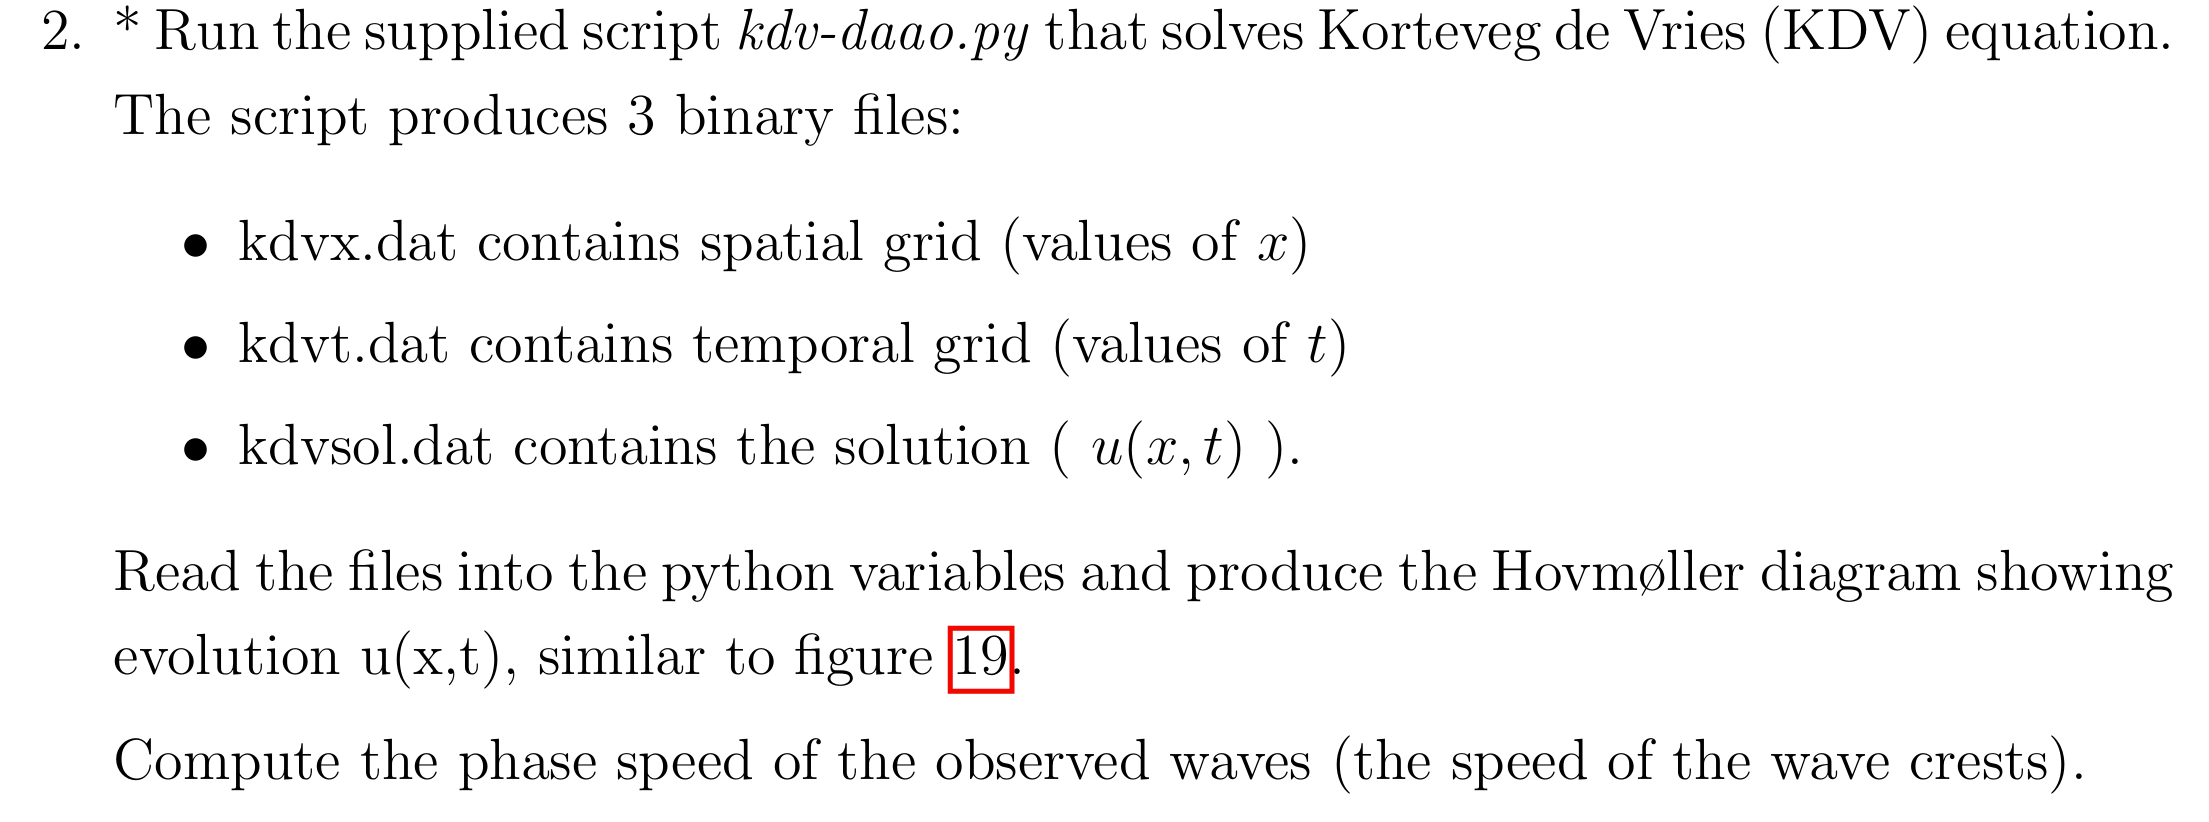

In [ ]:
t[j]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import argrelmax

# Load data from the .dat files
x = np.load('kdvx.dat')
t = np.load('kdvt.dat')
y = np.load('kdvsol.dat')

# Set up the meshgrid for plotting
X, T = np.meshgrid(x, t)

# Computing wavelength
j = len(t) // 2
yx_slice = y[j, :]
x_peaks_idx = argrelmax(yx_slice, order=2)[0]
x_peaks = x[x_peaks_idx]
dx = np.diff(x_peaks)
wavelength = np.mean(dx)

# Computing period
i = len(x) // 2
yt_slice = y[:, i]
t_peaks_idx = argrelmax(yt_slice, order=2)[0]
t_peaks = t[t_peaks_idx]
dt = np.diff(t_peaks)
period = np.mean(dt)

# Computing wave speed
wave_speed = wavelength / period
print(f"Wave speed: {wave_speed:.4f} m/s")

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))

data = ax.pcolormesh(X, T, y)
ax.scatter(x_peaks, t[j] * np.ones_like(x_peaks), color='red', label=f"Crests along t={t[j]:.1f}")
ax.scatter(x[i] * np.ones_like(t_peaks), t_peaks, color='blue', label=f"Crests along x={x[i]:.1f}")
ax.set_title("Korteveg de Vries on a Periodic Domain", fontsize=16)
ax.set_xlabel('x / m', fontsize=14)
ax.set_ylabel('t / s', fontsize=14)
ax.legend(loc='lower right', fontsize=12)

text = (
    f"Period = {period:.4f} s\n"
    f"Wavelength = {wavelength:.4f} m\n"
    rf"Wave Speed = {wave_speed:.4f} m s$^{{-1}}$"
)

ax.text(0.02, 0.98, text,
        transform=ax.transAxes,   # use axes (0–1) coordinates
        ha='left',
        va='top',
        fontsize=12,
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.4'))

cbar = fig.colorbar(ax=ax,
                    mappable=data,
                    orientation='vertical'
)
cbar.set_label('Wave Amplitude / m', fontsize=14)


plt.show()

In [ ]:
y_slice

In [ ]:
crests = argrelmax(y[0], order=2)

fig, ax = plt.subplots()
ax.plot(X[0], y[0])

In [ ]:
crests

In [ ]:
crests

In [ ]:
import numpy as np

# Assume x, t, y already loaded as in your script
# x is 1D (space), t is 1D (time), y has shape (len(t), len(x))

# 1. Find crest position for each time (max over x)
crest_idx = np.argmax(y, axis=1)      # shape (len(t),)
crests_x = x[crest_idx]               # crest position vs time

# 2. Handle periodicity by unwrapping
# Domain length (assuming uniform grid and periodicity)
L = x[-1] - x[0] + (x[1] - x[0])      # or L = x[-1] - x[0] + dx

# Map positions to angles, unwrap, then map back
theta = 2 * np.pi * crests_x / L
theta_unwrapped = np.unwrap(theta)
crests_x_unwrapped = (theta_unwrapped / (2 * np.pi)) * L

# 3. Fit a line x(t) = v t + x0
coeffs = np.polyfit(t, crests_x_unwrapped, 1)
v = coeffs[0]   # this is dx/dt (phase speed)

print("Estimated crest speed dx/dt =", v)


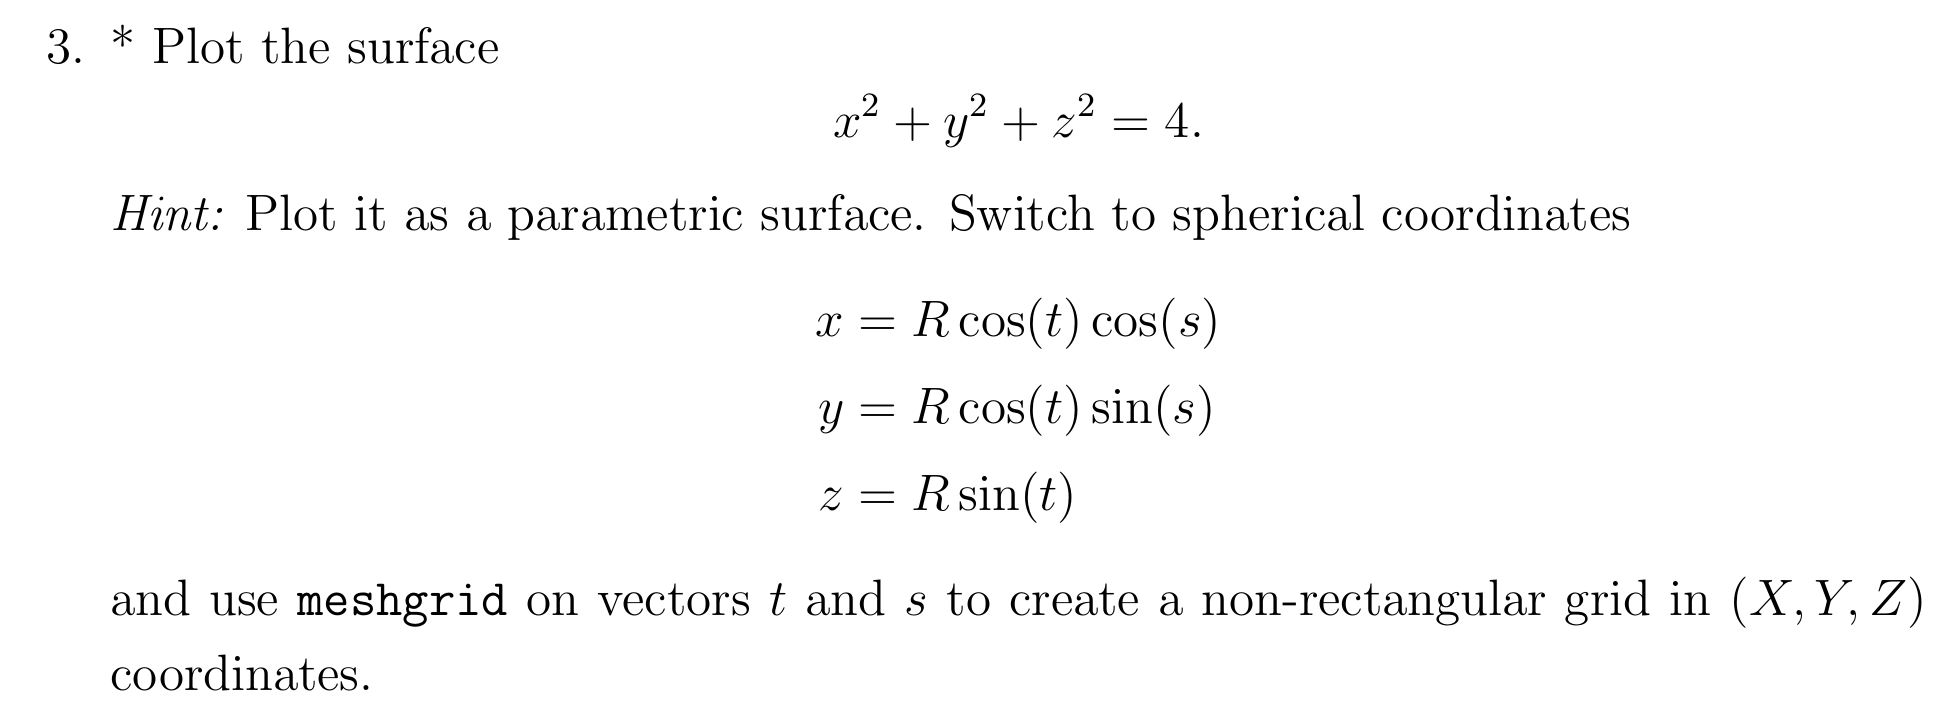

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import numpy as np

R = 2.0
s = np.linspace(0, 2*np.pi, 300)
t = np.linspace(0, 2*np.pi, 300)
S, T = np.meshgrid(s, t)

x = R * np.cos(T) * np.cos(S)
y = R * np.cos(T) * np.sin(S)
z = R * np.sin(T)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='3d'))
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none')
ax.set_title("Sphere: $x^2 + y^2 + z^2 = 4$", fontsize=16)
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.set_zlabel("z", fontsize=14)
ax.set_box_aspect([1, 1, 1])
ax.grid()

plt.show()

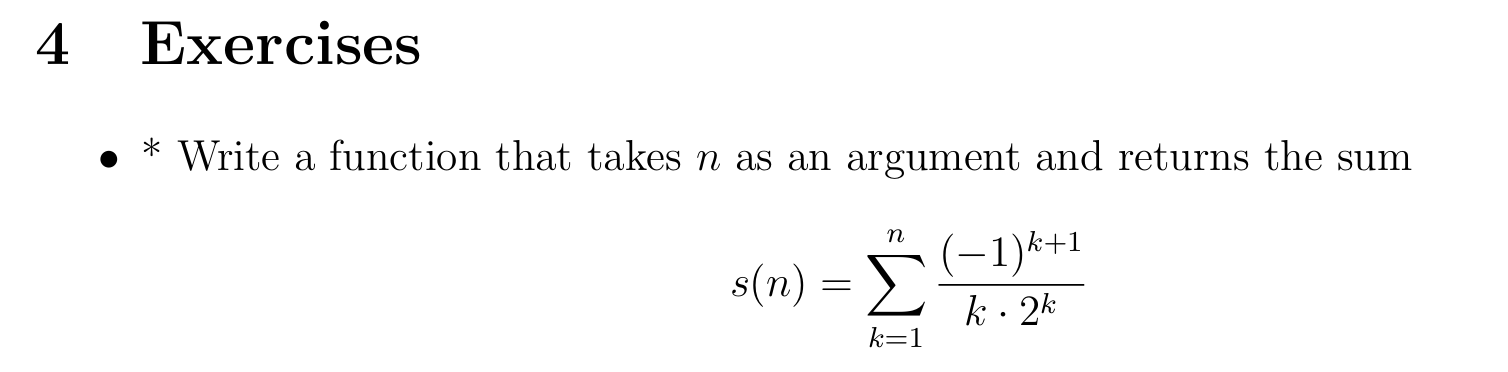
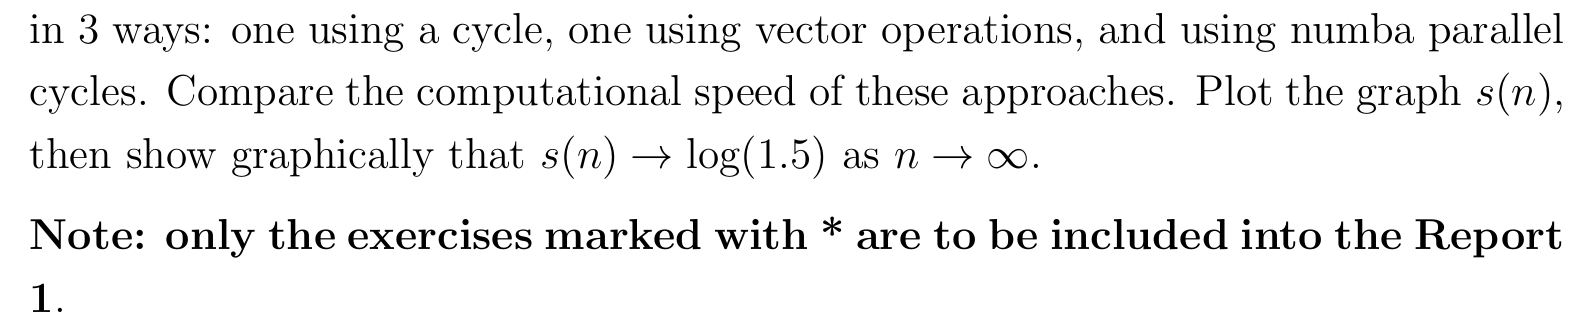

In [ ]:
from time import time
from numba import jit

import matplotlib.pyplot as plt
import numpy as np

def s1(n: int) -> float:
    """Computes the sum using Python cycles"""
    sum = 0
    for i in range(1, n):
        sum += (-1)**(i + 1) * np.exp(-i * np.log(2)) / i
    return sum

def s2(n: int) -> np.ndarray:
    """Computes the sum using Python vectorization"""
    x = np.arange(1, n, dtype=float)
    terms = (-1)**(x + 1) * np.exp(-x * np.log(2)) / x
    return terms

@jit
def s3(n: int) -> float:
    """Computes the sum using Python cycles and Jit"""
    sum = 0
    for i in range(1, n):
        sum += (-1)**(i + 1) * np.exp(-i * np.log(2)) / i
    return sum

# Testing integer
n: int = 50_000_000

# Compute sum using cycles
s1_start = time()
s1 = s1(n)
s1_end = time()

s1_time = s1_end - s1_start

# Compute sum using vectorization
s2_start = time()
s2 = s2(n)
s2_sum = float(s2.sum())
s2_end = time()

s2_time = s2_end - s2_start

# Compute sum numba
s3_start = time()
s3 = s3(n)
s3_end = time()

s3_time = s3_end - s3_start

# Print statistics
print(f"Sum using cycles: {s1:.3f}.")
print(f"Cycle computation time: {s1_time:.3f} seconds.\n")

print(f"Sum using vectorization: {s2_sum:.3f}.")
print(f"Vectorized computation time: {s2_time:.3f} seconds\n")

print(f"Sum using numba: {s3:.3f}.")
print(f"Numba computation time: {s3_time:.3f} seconds\n")

# Plotting
x1 = np.arange(1, n)
s2_cumsum = s2.cumsum()

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x1,
        s2_cumsum,
        color='black',
        linewidth=0.7,
        label=r'$s(n) = \sum_{k=1}^n \dfrac{(-1)^{k+1}}{k\cdot 2^k}$'
)
ax.axhline(y=np.log(1.5), linestyle=':', color='red', label='log(1.5)', alpha=0.5)
ax.set_xlabel('n')
ax.set_ylabel('s(n)')
ax.set_title(r"Graph of the cumulative sum $s(n)$")
ax.set_xscale('log')
ax.set_xlim(1, None)
ax.set_ylim(0.35, 0.51)

plt.show()

In [ ]:
# Plotting
x1 = np.arange(1, n)
s2_cumsum = s2.cumsum()

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x1,
        s2_cumsum,
        color='black',
        linewidth=0.7,
        label=r'$s(n) = \sum_{k=1}^n \dfrac{(-1)^{k+1}}{k\cdot 2^k}$'
)
ax.axhline(y=np.log(1.5), linestyle=':', color='red', label=r'$\log{(1.5)}$', alpha=0.8)
ax.set_xlabel('n')
ax.set_ylabel('s(n)')
ax.set_title(r"Graph of the cumulative sum $s(n)$")
ax.set_xscale('log')
ax.set_xlim(1, None)
ax.set_ylim(0.35, 0.51)
ax.legend(loc='upper right')

plt.show()

In [ ]:
def a(n: int) -> np.ndarray:
    x = np.arange(1, n, dtype=float)
    terms = (-1)**(x + 1) * np.exp(-x * np.log(2)) / x
    return terms.cumsum()

N = 20_000_000

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(np.arange(1, N), a(N))
ax.set_xscale('log')

plt.show()

In [ ]:
import numpy as np

def u_field(x, y):
    """Return the zonal wind field for a given longitude and latitude"""
    return -10 * np.sin(2 * np.pi * y / 180) * (np.cos(np.pi * x / 180))**2

def v_field(x, y):
    """Return the meridional wind field for a given longitude and latitude"""
    return 10 * (np.cos(np.pi * y / 180))**2 * np.sin(2 * np.pi * x / 180)

def windspeed(u, v):
    """Return the windspeed given the zonal and meridional wind field"""
    return np.sqrt(u**2 + v**2)

# Set up lat / lon grid
x = np.linspace(-180, 180, 1_000)
y = np.linspace(-90, 90, 1_000)
X, Y = np.meshgrid(x, y)

# Compute fields
U = u_field(X, Y)
V = v_field(X, Y)
speed = windspeed(U, V)

zonal_mean = np.average(speed, axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(y, zonal_mean, color='red')
ax.set_xlabel("Latitude")
ax.set_ylabel("Zonally averaged wind speed")
ax.set_title("Zonally averaged wind speed vs latitude")
ax.set_xlim(-90, 90)
ax.set_ylim(0, None)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def u_field(x, y):
    """Return the zonal wind field for a given longitude and latitude"""
    return -10 * np.sin(2 * np.pi * y / 180) * (np.cos(np.pi * x / 180))**2

def v_field(x, y):
    """Return the meridional wind field for a given longitude and latitude"""
    return 10 * (np.cos(np.pi * y / 180))**2 * np.sin(2 * np.pi * x / 180)

def windspeed(u, v):
    """Return the windspeed given the zonal and meridional wind field"""
    return np.sqrt(u**2 + v**2)

# Set up lat / lon grid
x = np.linspace(-180, 180, 1_000)
y = np.linspace(-90, 90, 1_000)
X, Y = np.meshgrid(x, y)

# Compute fields
U = u_field(X, Y)
V = v_field(X, Y)
speed = windspeed(U, V)

zonal_mean = np.average(speed, axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(y, zonal_mean, color='red')
ax.set_xlabel("Latitude")
ax.set_ylabel("Zonally averaged wind speed")
ax.set_title("Zonally averaged wind speed vs latitude")
ax.set_xlim(-90, 90)
ax.set_ylim(0, None)

plt.show()

In [ ]:
import calendar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(3)

data = np.random.randint(27,size=(10,12))

df = pd.DataFrame(
    data,
    index=np.arange(1990, 2000),
    columns=list(calendar.month_name)[1:]
)

start_year, end_year = 1990, 1999
yearly_sunny_days = df.sum(axis=1).to_numpy()
monthly_mean_sunny_days = df.mean(axis=0).to_numpy()

winter = df[['December', 'January', 'February']].sum().sum()
spring = df[['March', 'April', 'May']].sum().sum()
summer = df[['June', 'July', 'August']].sum().sum()
autumn = df[['September', 'October', 'November']].sum().sum()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 20))

ax1.plot(df.index, yearly_sunny_days, color='blue')
ax1.set_xlabel("Year", fontsize=14)
ax1.set_ylabel("Number of Sunny days", fontsize=14)
ax1.set_title(f"Annual number of Sunny days at location ({start_year}-{end_year})", fontsize=16)
ax1.set_xlim(1990, 1999)
ax1.set_ylim(100, 200)
ax1.tick_params(axis='x', rotation=45)

ax2.bar(df.columns, monthly_mean_sunny_days, color='red')
ax2.set_xlabel("Month", fontsize=14)
ax2.set_ylabel(f"Average number of Sunny days per month", fontsize=14)
ax2.set_title(f"Average number of Sunny days per month at location ({start_year}-{end_year})", fontsize=16)
ax2.set_ylim(0, 20)
ax2.tick_params(axis='x', rotation=45)

ax3.pie(
    [winter, spring, summer, autumn],
    labels=['Winter', 'Spring', 'Summer', 'Autumn'],
    colors=['cyan', 'olive', 'red', 'orange'],
    startangle=90,
    autopct=f"%.1f%%"
)
ax3.axis('equal')

fig.suptitle(f"Summary plot for number of sunny days ({start_year}-{end_year})", y=1.0, fontsize=20)
plt.tight_layout()

plt.show()

In [ ]:
import calendar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(3)

data = np.random.randint(27, size=(10,12))

df = pd.DataFrame(
    data,
    index=np.arange(1990, 2000),
    columns=list(calendar.month_name)[1:]
)

start_year, end_year = 1990, 1999
yearly_sunny_days = df.sum(axis=1).to_numpy()
monthly_mean_sunny_days = df.mean(axis=0).to_numpy()

winter = df[['December', 'January', 'February']].sum().sum()
spring = df[['March', 'April', 'May']].sum().sum()
summer = df[['June', 'July', 'August']].sum().sum()
autumn = df[['September', 'October', 'November']].sum().sum()

data = [winter, spring, summer, autumn]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 20))

ax1.plot(df.index, yearly_sunny_days, color='blue')
ax1.set_xlabel("Year", fontsize=14)
ax1.set_ylabel("Number of Sunny days", fontsize=14)
ax1.set_title(f"Annual number of Sunny days at location ({start_year}-{end_year})", fontsize=16)
ax1.set_xlim(1990, 1999)
ax1.set_ylim(100, 200)
ax1.tick_params(axis='x', rotation=45)

ax2.bar(df.columns, monthly_mean_sunny_days, color='red')
ax2.set_xlabel("Month", fontsize=14)
ax2.set_ylabel(f"Average number of Sunny days per month", fontsize=14)
ax2.set_title(f"Average number of Sunny days per month at location ({start_year}-{end_year})", fontsize=16)
ax2.set_ylim(0, 20)
ax2.tick_params(axis='x', rotation=45)

ax3.pie(
    data,
    labels=['Winter', 'Spring', 'Summer', 'Autumn'],
    colors=['cyan', 'limegreen', 'red', 'orange'],
    startangle=90,
    autopct=lambda p: f'{p:.1f}%',
    wedgeprops=dict(linewidth=0.5, edgecolor='black')
)
ax3.axis('equal')
ax3.set_title("Seasonal share of Sunny Days (1990-1999)", fontsize=16)

fig.suptitle(f"Summary plot for number of sunny days ({start_year}-{end_year})", y=1.0, fontsize=20)
plt.tight_layout()

plt.show()

In [ ]:
f"%.1f%%"

In [ ]:
import numpy as np

# Sample data: 10 years × 12 months
data = np.random.randint(1, 100, size=(10, 12))  # Random data for example

# Define month indices (0-11)
# Jan=0, Feb=1, Mar=2, Apr=3, May=4, Jun=5
# Jul=6, Aug=7, Sep=8, Oct=9, Nov=10, Dec=11

seasons = {
    'Winter': [11, 0, 1],   # Dec, Jan, Feb
    'Spring': [2, 3, 4],    # Mar, Apr, May
    'Summer': [5, 6, 7],    # Jun, Jul, Aug
    'Autumn': [8, 9, 10]    # Sep, Oct, Nov
}

# Function to get seasonal sum
def seasonal_sum(arr, season):
    return arr[:, seasons[season]].sum()

# Calculate sums for all seasons
seasonal_sums = {season: seasonal_sum(data, season) for season in seasons}

print(seasonal_sums)
# Output: {'Winter': 1200, 'Spring': 1500, ...}

In [ ]:
winter_months = ['December', 'January', 'February']
spring_months = ['March', 'April', 'May']
summer_months = ['June', 'July', 'August']
Autumn_months = ['September', 'October', 'November']
df[winter_months].sum().sum()

In [ ]:
df

In [ ]:
def s2(n):
    x = np.arange(1, n, dtype=float)
    terms = (-1)**(x + 1) * np.exp(-x * np.log(2)) / x
    return float(terms.sum())

s2(1_000_000)

In [ ]:
from scipy.signal import argrelmax
import numpy as np
import matplotlib.pyplot as plt

# Load data
x = np.load('kdvx.dat')
t = np.load('kdvt.dat')
u = np.load('kdvsol.dat')

nt, nx = u.shape

all_peaks = []

for n in range(nt):
    peaks = argrelmax(u[n], order=3)[0]
    all_peaks.append(peaks)

all_peaks

In [ ]:
import numpy as np

# Load data from the .dat files
x = np.load('kdvx.dat')
t = np.load('kdvt.dat')
y = np.load('kdvsol.dat')

# Find crest positions at each time step
crest_positions = []
for i, time_slice in enumerate(y):
    # Find local maxima
    from scipy.signal import argrelmax
    peaks, = argrelmax(time_slice)
    if len(peaks) > 0:
        # Get the position of the first crest (or average of all crests)
        crest_pos = x[peaks[0]]  # First crest
        crest_positions.append((t[i], crest_pos))

# Convert to arrays
times = np.array(crest_positions)[:, 0]
positions = np.array(crest_positions)[:, 1]

# Calculate wave speed dx/dt
wave_speed = np.diff(positions) / np.diff(times)
average_speed = np.mean(wave_speed)

print(f"Average wave speed: {average_speed:.6f} m/s")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import argrelmax

# Load data
x = np.load('kdvx.dat')
t = np.load('kdvt.dat')
y = np.load('kdvsol.dat')

# Find the index in x closest to x = 10
x_target = 10.0
x_idx = np.argmin(np.abs(x - x_target))

print(f"Closest x to 10.0 is at index {x_idx}, x = {x[x_idx]:.6f}")

# Extract the time series at x = 10
y_at_x10 = y[:, x_idx]  # shape: (len(t),)

# Find local maxima in time (i.e., crests at x = 10)
# argrelmax returns indices of local maxima
max_indices = argrelmax(y_at_x10, order=2)[0]  # order=2 avoids noise

if len(max_indices) == 0:
    print("No local maxima found at x = 10.")
else:
    # Get the first (earliest) time where a maximum occurs
    first_max_idx = max_indices[0]
    first_t = t[first_max_idx]
    first_y = y_at_x10[first_max_idx]

    print(f"First local maximum at x = 10 occurs at t = {first_t:.6f} s")
    print(f"Amplitude at that point: y = {first_y:.6f}")

    # Optional: Plot the time series at x = 10
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(t, y_at_x10, 'b-', label='y(t) at x = 10')
    ax.plot(t[first_max_idx], first_y, 'ro', markersize=8, label=f'First max at t = {first_t:.6f}')
    ax.set_xlabel('t / s')
    ax.set_ylabel('y / m')
    ax.set_title(f'Wave amplitude at x = 10.0 (closest: x = {x[x_idx]:.6f})')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
x_idx

In [ ]:
max_indices = argrelmax(y_at_x10, order=2)
t[max_indices[0][1]]

In [ ]:
np.diff(max_indices)[0]

In [ ]:
import numpy as np
from scipy.signal import argrelmax

# --- Load data ---
x = np.load('kdvx.dat')
t = np.load('kdvt.dat')
y = np.load('kdvsol.dat')   # shape: (Nt, Nx)

Nt, Nx = y.shape

# --- Storage for crest positions ---
crest_x = np.zeros(Nt)
crest_idx = np.zeros(Nt, dtype=int)

# --- Step 1: initialize at first time ---
peaks = argrelmax(y[0, :])[0]

# choose dominant crest (largest amplitude)
crest_idx[0] = peaks[np.argmax(y[0, peaks])]
crest_x[0] = x[crest_idx[0]]

# --- Step 2: track crest forward in time ---
window = 6  # tuning parameter (depends on resolution & speed)

for j in range(1, Nt):
    prev_idx = crest_idx[j-1]

    xmin = max(0, prev_idx - window)
    xmax = min(Nx, prev_idx + window)

    local = y[j, xmin:xmax]

    local_peaks = argrelmax(local)[0]

    if len(local_peaks) > 0:
        # choose peak closest to previous position
        candidates = xmin + local_peaks
        crest_idx[j] = candidates[np.argmin(np.abs(candidates - prev_idx))]
    else:
        # fallback: take max in window
        crest_idx[j] = xmin + np.argmax(local)

    crest_x[j] = x[crest_idx[j]]

# --- Step 3: compute dx/dt ---
dx_dt = np.gradient(crest_x, t)

# --- Optional: mean speed ---
mean_speed = np.mean(dx_dt)

print("Mean wave speed:", mean_speed)

In [ ]:
import calendar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(3)

data = np.random.randint(27, size=(10,12))

df = pd.DataFrame(
    data,
    index=np.arange(1990, 2000),
    columns=list(calendar.month_name)[1:]
)

start_year, end_year = 1990, 1999
yearly_sunny_days = df.sum(axis=1).to_numpy()
monthly_mean_sunny_days = df.mean(axis=0).to_numpy()

winter = df[['December', 'January', 'February']].sum().sum()
spring = df[['March', 'April', 'May']].sum().sum()
summer = df[['June', 'July', 'August']].sum().sum()
autumn = df[['September', 'October', 'November']].sum().sum()

data = [winter, spring, summer, autumn]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 20))

ax1.plot(df.index, yearly_sunny_days, color='blue')
ax1.set_xlabel("Year", fontsize=14)
ax1.set_ylabel("Number of Sunny days", fontsize=14)
ax1.set_title(f"Annual number of Sunny days at location ({start_year}-{end_year})", fontsize=16)
ax1.set_xlim(1990, 1999)
ax1.set_ylim(100, 200)
ax1.tick_params(axis='x', rotation=45)

ax2.bar(df.columns, monthly_mean_sunny_days, color='red')
ax2.set_xlabel("Month", fontsize=14)
ax2.set_ylabel(f"Average number of Sunny days per month", fontsize=14)
ax2.set_title(f"Average number of Sunny days per month at location ({start_year}-{end_year})", fontsize=16)
ax2.set_ylim(0, 20)
ax2.tick_params(axis='x', rotation=45)

ax3.pie(
    data,
    labels=['Winter', 'Spring', 'Summer', 'Autumn'],
    colors=['cyan', 'limegreen', 'red', 'orange'],
    startangle=90,
    autopct=lambda p: f'{p:.1f}%',
    wedgeprops=dict(linewidth=0.5, edgecolor='black')
)
ax3.axis('equal')
ax3.set_title("Seasonal share of Sunny Days (1990-1999)", fontsize=16)

fig.suptitle(f"Summary plot for number of sunny days ({start_year}-{end_year})", y=1.0, fontsize=20)
plt.tight_layout()

plt.show()

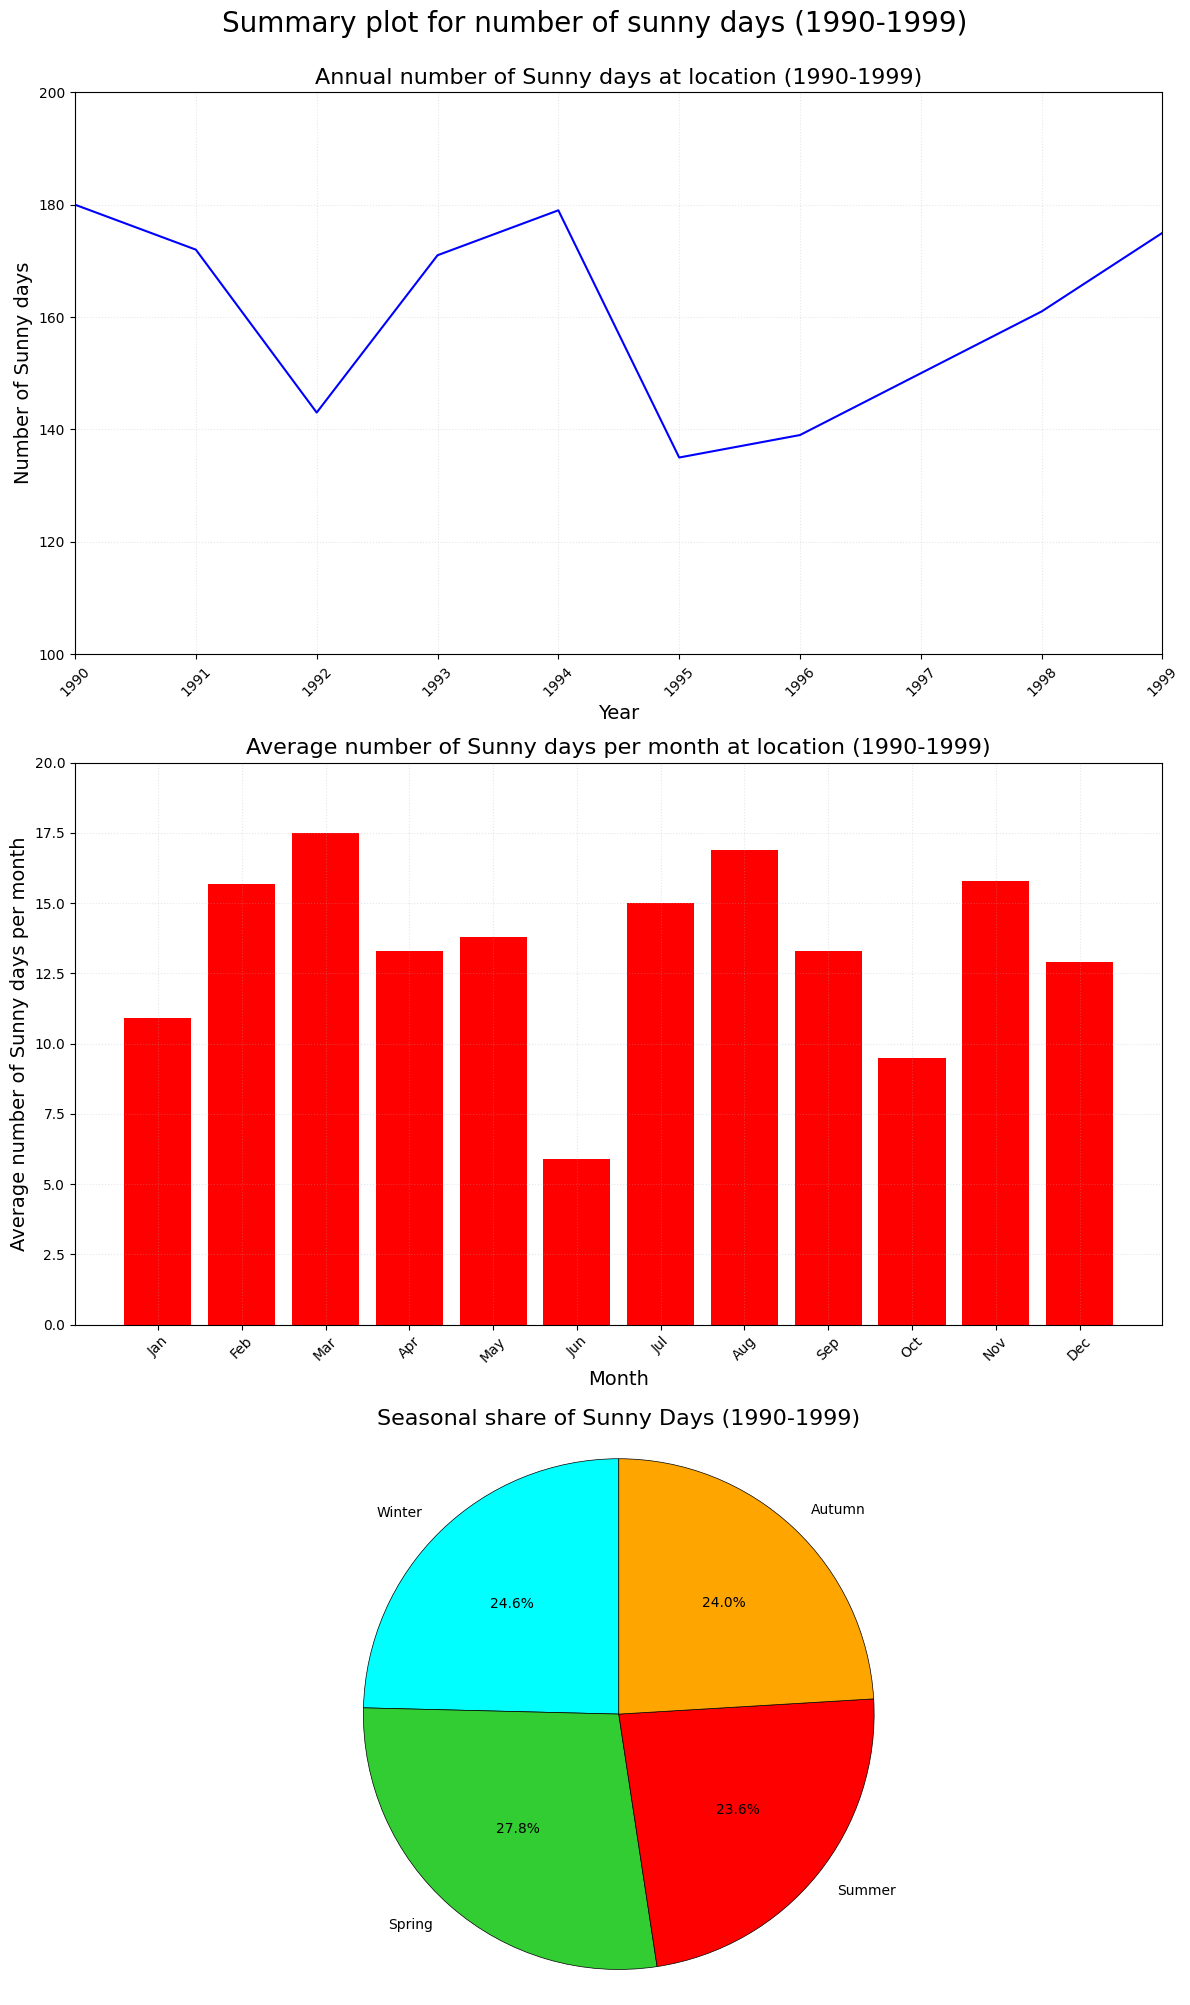

In [29]:
import calendar

import matplotlib.pyplot as plt
import numpy as np


np.random.seed(3)

data = np.random.randint(27, size=(10,12))

# Numer of sunny days in each year.
yearly_sunny_days = df.sum(axis=1)
start_year, end_year = 1990, 1999
years = np.arange(start_year, end_year + 1)

# Ave number of sunny days for each month.
ave_monthly_sunny_days = data.mean(axis=0)
months = np.array(calendar.month_abbr[1:])

# Seasonal share of sunny days.
winter_sunny_days = data[:, [11, 0, 1]].sum()
spring_sunny_days = data[:, [2, 3, 4]].sum()
summer_sunny_days = data[:, [5, 6, 7]].sum()
autumn_sunny_days = data[:, [8, 9, 10]].sum()

seasonal_sunny_days = [winter_sunny_days, spring_sunny_days, summer_sunny_days, autumn_sunny_days]


# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 20))

ax1.plot(years, yearly_sunny_days, color='blue')
ax1.set_xlabel("Year", fontsize=14)
ax1.set_ylabel("Number of Sunny days", fontsize=14)
ax1.set_title(f"Annual number of Sunny days at location ({start_year}-{end_year})", fontsize=16)
ax1.set_xlim(start_year, end_year)
ax1.set_ylim(100, 200)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(linestyle=':', alpha=0.3)

ax2.bar(months, ave_monthly_sunny_days, color='red')
ax2.set_xlabel("Month", fontsize=14)
ax2.set_ylabel(f"Average number of Sunny days per month", fontsize=14)
ax2.set_title(f"Average number of Sunny days per month at location ({start_year}-{end_year})", fontsize=16)
ax2.set_ylim(0, 20)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(linestyle=':', alpha=0.3)

ax3.pie(
    seasonal_sunny_days,
    labels=['Winter', 'Spring', 'Summer', 'Autumn'],
    colors=['cyan', 'limegreen', 'red', 'orange'],
    startangle=90,
    autopct=lambda p: f'{p:.1f}%',
    wedgeprops=dict(linewidth=0.5, edgecolor='black')
)
ax3.axis('equal')
ax3.set_title("Seasonal share of Sunny Days (1990-1999)", fontsize=16)

fig.suptitle(f"Summary plot for number of sunny days ({start_year}-{end_year})", y=1.0, fontsize=20)
plt.tight_layout()

plt.show()

In [ ]:
winter

In [ ]:
data